Importing all the required librarires.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import string
from google.colab import files
import warnings

warnings.filterwarnings('ignore')

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

train_df.info()
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     40000 non-null  object
 1   sentiment  40000 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


,review,sentiment
0,I caught this little gem totally by accident b...,positive
1,I can't believe that I let myself into this mo...,negative
2,*spoiler alert!* it just gets to me the nerve ...,negative
3,If there's one thing I've learnt from watching...,negative
4,"I remember when this was in theaters, reviews ...",negative


# EDA

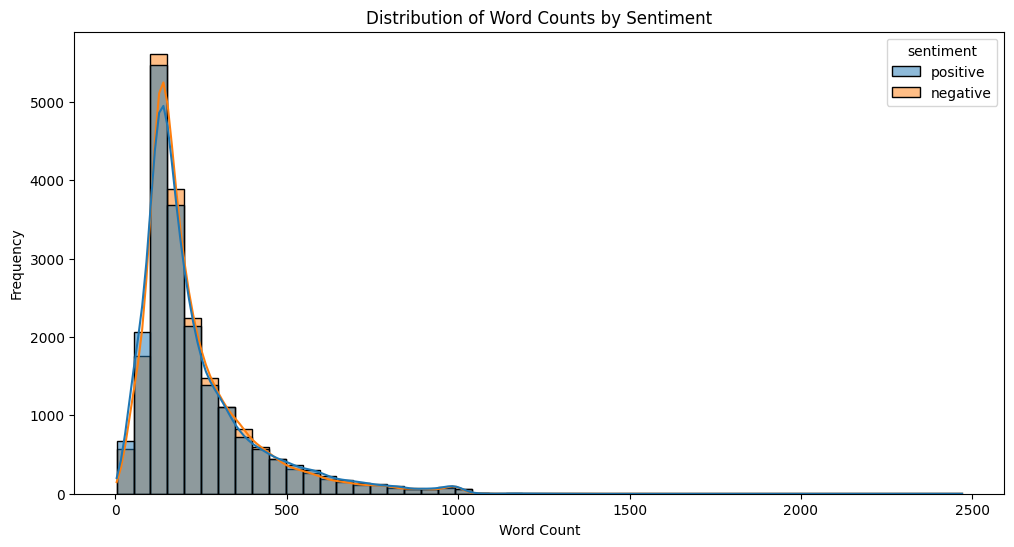

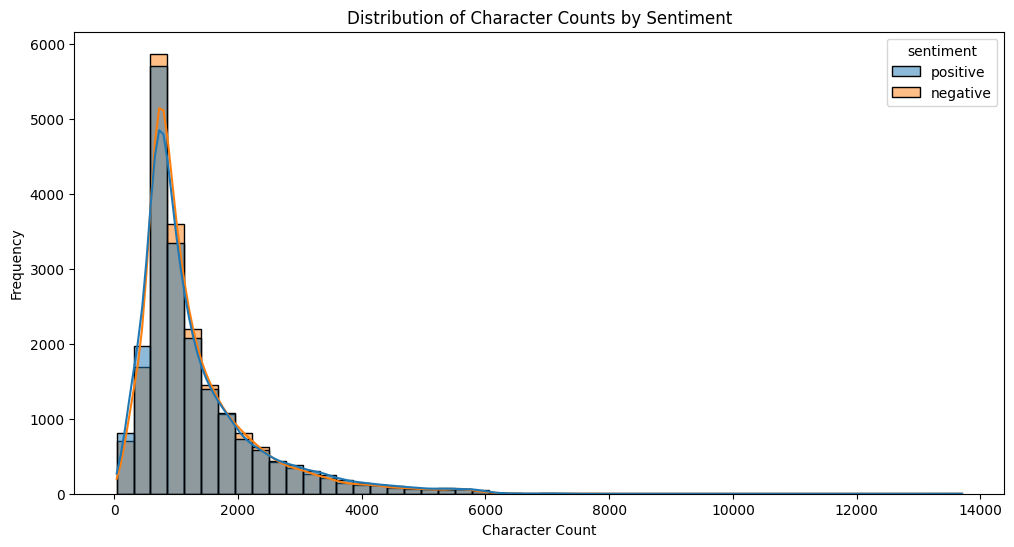

In [ ]:
# Calculate word and character counts
train_df['word_count'] = train_df['review'].apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['review'].apply(len)

# Word count distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='word_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Word Counts by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# Character count distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='char_count', hue='sentiment', bins=50, kde=True)
plt.title("Distribution of Character Counts by Sentiment")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

-> **Word Count Distribution:** Positive and negative reviews generally follow a similar distribution. Most reviews fall between 50 to 200 words.

-> **Character Count Distribution:** Both sentiments show a similar pattern for character counts, with most reviews containing 300 to 800 characters.

This indicates no significant outliers in text length.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


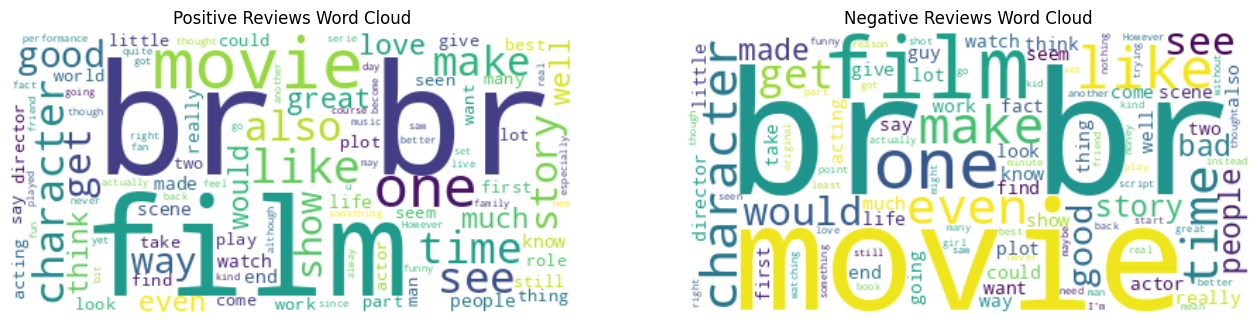

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

positive_reviews = " ".join(train_df[train_df['sentiment'] == 'positive']['review'])
negative_reviews = " ".join(train_df[train_df['sentiment'] == 'negative']['review'])

positive_wordcloud = WordCloud(stopwords=stop_words, background_color="white", max_words=100).generate(positive_reviews)
negative_wordcloud = WordCloud(stopwords=stop_words, background_color="white", max_words=100).generate(negative_reviews)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(positive_wordcloud, interpolation='bilinear')
ax[0].set_title("Positive Reviews Word Cloud")
ax[0].axis('off')
ax[1].imshow(negative_wordcloud, interpolation='bilinear')
ax[1].set_title("Negative Reviews Word Cloud")
ax[1].axis('off')
plt.show()

-> **Positive Reviews Word Cloud:** Common words include "love," "great," "amazing," and "best," highlighting positive sentiment keywords.

-> **Negative Reviews Word Cloud:** Common words include "bad," "worst," "boring," and "waste," indicating dissatisfaction.

In [ ]:
# Check for duplicate reviews
duplicate_count = train_df.duplicated(subset='review').sum()
print(f"Number of duplicate reviews: {duplicate_count}")

Number of duplicate reviews: 272


Since the number of duplicates is small (0.5%), removing them is generally a good idea to ensure clean data and avoid overfitting.

In [ ]:
# Remove duplicate reviews
train_df = train_df.drop_duplicates(subset='review').reset_index(drop=True)
print(f"Dataset after removing duplicates: {train_df.shape}")

Dataset after removing duplicates: (39728, 4)


# Text Pre-processing

## Tokenization

In [ ]:
nltk.download('punkt_tab')

# Example of tokenization for a single review
sample_review = train_df['review'][0]
tokens = word_tokenize(sample_review)
print(f"Original Review: {sample_review}")
print(f"Tokenized Review: {tokens}")

# Apply tokenization to the entire dataset
train_df['tokens'] = train_df['review'].apply(word_tokenize)
train_df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Review: I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it's even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!
Tokenized Review: ['I', 'caught', 'this', 'little', 'gem', 'totally', 'by', 'accident', 'b

,review,sentiment,word_count,char_count,tokens
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,..."


So, this lays the foundation for further preprocessing like removing stop-words and stemming/lemmatization.

## Stop-word Filtering

In [ ]:
# Define stop words
stop_words = set(stopwords.words('english'))

# Function to remove stop words
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

# Apply stop-word filtering
train_df['tokens_no_stopwords'] = train_df['tokens'].apply(remove_stopwords)
train_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl..."


Stop words like "the," "is," and "and" do not contribute to the sentiment and are removed.

This step reduces noise and improves focus on sentiment-related words.

## Comparison of Stemming vs Lemmatization

### Stemming

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Function to apply stemming
def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

# Apply stemming
train_df['tokens_stemmed'] = train_df['tokens_no_stopwords'].apply(stem_tokens)
train_df.head()

,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...","[caught, littl, gem, total, accid, back, 1980,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav...","[ca, n't, believ, let, movi, accomplish, favor..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,...","[*, spoiler, alert, !, *, get, nerv, peopl, re..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George...","['s, one, thing, 've, learnt, watch, georg, ro..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl...","[rememb, theater, ,, review, said, horribl, .,..."


-> The stemmed words often appear truncated and sometimes lose their semantic clarity.

-> This might introduce ambiguity, as the resulting stems might not always be meaningful in the context of the sentence.

-> The stemmed reviews become harder to interpret due to excessive truncation:

Example from Row 0:

Stemmed: ['caught', 'littl', 'gem', 'total', 'accid', 'back', '1980']

### Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply lemmatization
train_df['tokens_lemmatized'] = train_df['tokens_no_stopwords'].apply(lemmatize_tokens)
train_df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,review,sentiment,word_count,char_count,tokens,tokens_no_stopwords,tokens_stemmed,tokens_lemmatized
0,I caught this little gem totally by accident b...,positive,161,892,"[I, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...","[caught, littl, gem, total, accid, back, 1980,...","[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,negative,170,937,"[I, ca, n't, believe, that, I, let, myself, in...","[ca, n't, believe, let, movie, accomplish, fav...","[ca, n't, believ, let, movi, accomplish, favor...","[ca, n't, believe, let, movie, accomplish, fav..."
2,*spoiler alert!* it just gets to me the nerve ...,negative,69,468,"[*, spoiler, alert, !, *, it, just, gets, to, ...","[*, spoiler, alert, !, *, gets, nerve, people,...","[*, spoiler, alert, !, *, get, nerv, peopl, re...","[*, spoiler, alert, !, *, get, nerve, people, ..."
3,If there's one thing I've learnt from watching...,negative,314,1960,"[If, there, 's, one, thing, I, 've, learnt, fr...","['s, one, thing, 've, learnt, watching, George...","['s, one, thing, 've, learnt, watch, georg, ro...","['s, one, thing, 've, learnt, watching, George..."
4,"I remember when this was in theaters, reviews ...",negative,183,1015,"[I, remember, when, this, was, in, theaters, ,...","[remember, theaters, ,, reviews, said, horribl...","[rememb, theater, ,, review, said, horribl, .,...","[remember, theater, ,, review, said, horrible,..."


-> Words are converted to their base or dictionary form (lemma) while retaining their semantic clarity.

-> Lemmatization retains the original word forms, ensuring the tokens remain comprehensible.

Example from Row 0:

Lemmatized: ['caught', 'little', 'gem', 'totally', 'accident', 'back', '1980']

Thus, for our project i.e. Binary Sentiment Classification, lemmatization is the better choice because:

-> It preserves the grammatical and semantic integrity of words.

-> It ensures better context retention for sentiment-related terms.

-> Although slower than stemming, it provides more meaningful and interpretable tokens, which are crucial for building effective models.

## Vectorisation

### TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert reviews back to plain text after preprocessing
train_df['processed_text'] = train_df['tokens_lemmatized'].apply(lambda x: " ".join(x))

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(train_df['processed_text'])

print("TF-IDF Vectorized Shape:", X_tfidf.shape)

TF-IDF Vectorized Shape: (39728, 5000)


So here, this weighs words based on importance (rare terms get higher weight).

Example: ['good movie'] → [0.8, 0.4, 0.0, ...]

### Count Vectorisation

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Count Vectorization
count_vectorizer = CountVectorizer(max_features=5000)
X_count = count_vectorizer.fit_transform(train_df['processed_text'])

print("Count Vectorized Shape:", X_count.shape)

Count Vectorized Shape: (39728, 5000)


Whereas, this simply counts word frequency.

Example: ['good movie'] → [1, 1, 0, ...]

Thus, TF-IDF is preferred for binary sentiment classification because it reduces the impact of commonly occurring words like "movie."

So, let's use TF-IDF vectors for model building.

# Modeling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(train_df['tokens_lemmatized'], train_df['sentiment'], test_size=0.2, random_state=42)

In [ ]:
tfidf_vectorizer = TfidfVectorizer(analyzer=lambda x: x)  # TF-IDF

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

In [23]:
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (31782, 144991)


## Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_val_tfidf)
print("Logistic Regression with TF-IDF:")
print(classification_report(y_val, y_pred_lr))

Logistic Regression with TF-IDF:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      3961
    positive       0.89      0.90      0.89      3985

    accuracy                           0.89      7946
   macro avg       0.89      0.89      0.89      7946
weighted avg       0.89      0.89      0.89      7946



## SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_val_tfidf)

print("SVM with TF-IDF:")
print(classification_report(y_val, y_pred_svm))

SVM with TF-IDF:
              precision    recall  f1-score   support

    negative       0.90      0.90      0.90      3961
    positive       0.90      0.90      0.90      3985

    accuracy                           0.90      7946
   macro avg       0.90      0.90      0.90      7946
weighted avg       0.90      0.90      0.90      7946



## Naive Bayes

In [22]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_val_tfidf)

print("Naive Bayes with TF-IDF:")
print(classification_report(y_val, y_pred_nb))

Naive Bayes with TF-IDF:
              precision    recall  f1-score   support

    negative       0.85      0.89      0.87      3961
    positive       0.89      0.85      0.87      3985

    accuracy                           0.87      7946
   macro avg       0.87      0.87      0.87      7946
weighted avg       0.87      0.87      0.87      7946



## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_val_tfidf)

print("Random Forest Classifier with TF-IDF:")
print(classification_report(y_val, y_pred_rf))

Random Forest Classifier with TF-IDF:
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      3961
    positive       0.85      0.83      0.84      3985

    accuracy                           0.84      7946
   macro avg       0.84      0.84      0.84      7946
weighted avg       0.85      0.84      0.84      7946



# Observations and Conclusions

Here's the performance comparison table for all the models evaluated so far:


| **Model**               | **Precision** | **Recall** | **F1-Score** | **Accuracy** |
|--------------------------|---------------|------------|--------------|--------------|
| Logistic Regression      | 0.89          | 0.89       | 0.89         | 89%          |
| SVM                      | 0.90          | 0.90       | 0.90         | 90%          |
| Naive Bayes              | 0.87          | 0.87       | 0.87         | 87%          |
| Random Forest Classifier | 0.84          | 0.84       | 0.84         | 84%          |


**Observations:**

-> SVM emerges as the best-performing model with the highest precision, recall, F1-score, and accuracy across the board. This indicates that SVM is the most reliable in distinguishing between positive and negative sentiments.

-> Logistic Regression is a close second, slightly behind SVM in all metrics. It could still be a great choice due to its simplicity and interpretability.

-> Naive Bayes performs well but slightly lags behind SVM and Logistic Regression. This is expected, as Naive Bayes makes strong independence assumptions that may not fully align with the data.

-> Random Forest has the lowest performance among all models, primarily because it does not handle high-dimensional sparse data as effectively as the other models.

**Conclusions:**

Based on this comparison, SVM is the best-performing model. It will be chosen for further analysis and deployment. Logistic Regression can be kept as a secondary option due to its competitive performance and efficiency.